In [4]:
# import statement and helper functions
import rebound
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import signal

m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

## Time Series for Test Particle Saturn

376817.3167445681
Initial Energy: -8.880166071428572e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x7bbd2fa9b5f0, [0.0, 0.0, 0.002348194793041187]>


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:10<00:00, 9748.34it/s]


Final Energy: -8.880166071427099e-05
Energy Percent Change: 1.6589326033039926e-11 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x7bbd2f061d90, [0.0, 0.0, 0.002348194793041377]>
Megno Value: 12.569539991533254


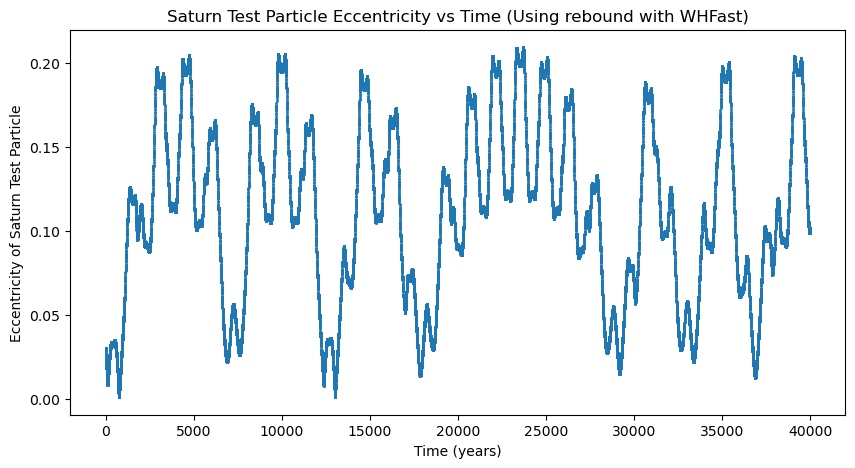

In [14]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=0,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))


print(1e7*2*np.pi/sim.particles[2].P)

sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    H_energy[i] = sim.energy()
    

e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))
print('Megno Value: ' + str(sim.megno()))

megno_test_particle = sim.megno()

e_test_particle = e_sat

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using rebound with WHFast)')
plt.show()

In [ ]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=0,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e7))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))


print(1e7*2*np.pi/sim.particles[2].P)

#sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    H_energy[i] = sim.energy()
    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))
#print('Megno Value: ' + str(sim.megno()))

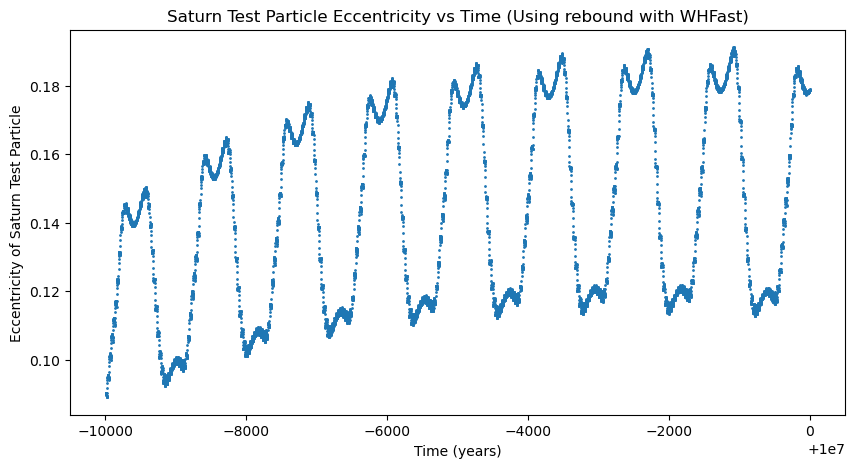

In [13]:
plt.figure(figsize=(10, 5))
plt.scatter(times[-10000:] / (2*np.pi), e_sat[-10000:], s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using rebound with WHFast)')
plt.show()

Initial Energy: -8.880166071428572e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x7bbd2f031480, [0.0, 0.0, 0.002348194793041187]>


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 18552.78it/s]


Final Energy: -8.880166071427099e-05
Energy Percent Change: 1.6589326033039926e-11 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x7bbd2f031480, [0.0, 0.0, 0.002348194793041377]>
Megno Value: 12.341712187168664


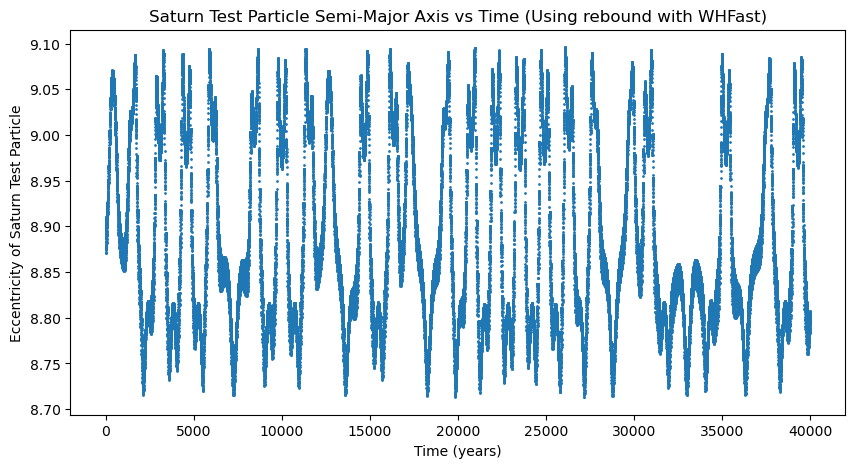

In [6]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=0,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
a_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))

sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    a_sat[i] = sim.particles[2].a
    H_energy[i] = sim.energy()
    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))
print('Megno Value: ' + str(sim.megno()))

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), a_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Semi-Major Axis vs Time (Using rebound with WHFast)')
plt.show()

## Time Series for Saturn With Mass

Initial Energy: -0.00010486980596760663
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x7bbd2f0604d0, [0.0, 0.0, 0.0032008467484405836]>


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:06<00:00, 16136.62it/s]


Final Energy: -0.00010486980593791454
Energy Percent Change: 2.8313293752189468e-08 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x7bbd2e6395a0, [0.0, 0.0, 0.0032008467484412]>
Megno Value: 2.9256294350335756


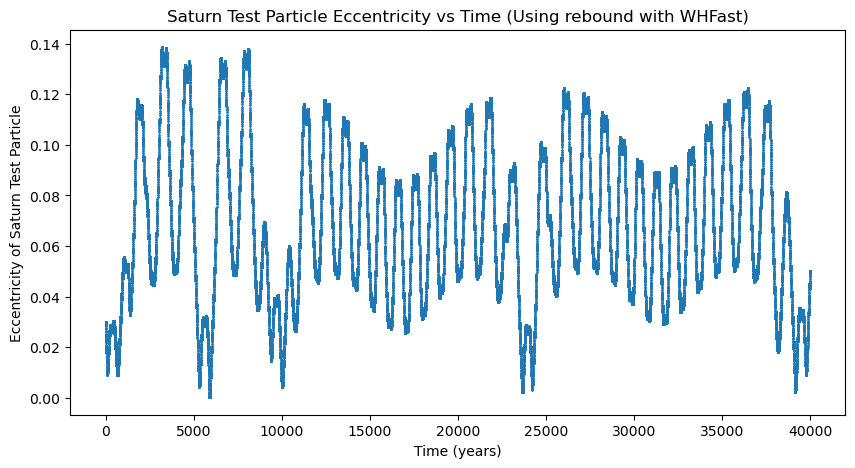

In [15]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))

sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    H_energy[i] = sim.energy()
    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))
print('Megno Value: ' + str(sim.megno()))

megno_mass_sat = sim.megno
e_mass_sat = e_sat

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using rebound with WHFast)')
plt.show()

In [ ]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
a_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))

sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    a_sat[i] = sim.particles[2].a
    H_energy[i] = sim.energy()
    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))
print('Megno Value: ' + str(sim.megno()))

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), a_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Semi-Major Axis vs Time (Using rebound with WHFast)')
plt.show()

## Superimposed Graph

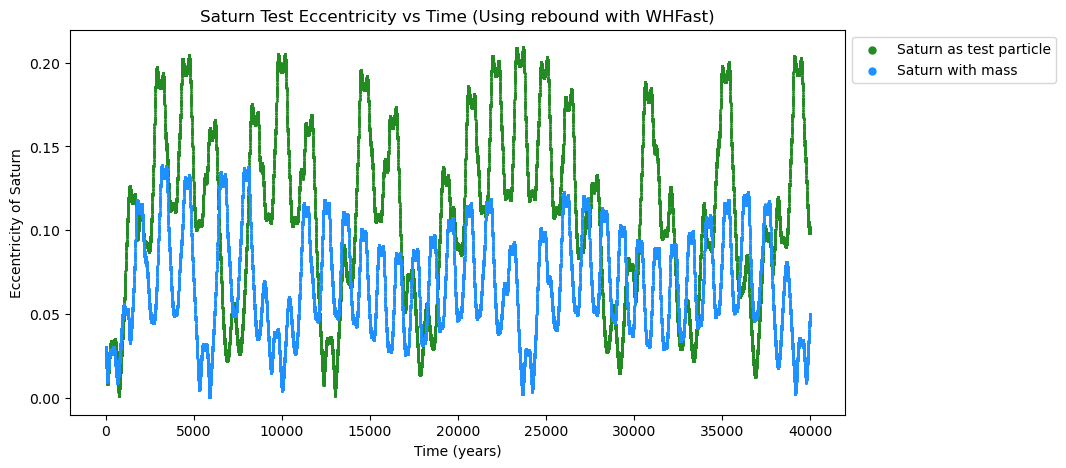

In [36]:
plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_test_particle,s=1, label = 'Saturn as test particle',color = 'forestgreen')
plt.scatter(times/(2*np.pi), e_mass_sat,s=1, label = 'Saturn with mass', color = 'dodgerblue')
plt.ylabel('Eccentricity of Saturn')
plt.xlabel("Time (years)")
plt.title('Saturn Test Eccentricity vs Time (Using rebound with WHFast)')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=5.0)
plt.show()

In [5]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=0,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
e_sat_test_particle = np.zeros(len(times))
H_energy = np.zeros(len(times))
a_sat_test_particle = np.zeros(len(times))


print(1e7*2*np.pi/sim.particles[2].P)

#sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    e_sat_test_particle[i] = sim.particles[2].e
    a_sat_test_particle[i] = sim.particles[2].a
    H_energy[i] = sim.energy()
    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))

sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
e_sat_mass = np.zeros(len(times))
H_energy = np.zeros(len(times))
a_sat_mass = np.zeros(len(times))

print(1e7*2*np.pi/sim.particles[2].P)

#sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    H_energy[i] = sim.energy()
    e_sat_mass[i] = sim.particles[2].e
    a_sat_mass[i] = sim.particles[2].a

    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))

376817.3167445681
Initial Energy: -8.880166071428572e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x7ca62aabe0d0, [0.0, 0.0, 0.002348194793041187]>


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [05:03<00:00, 329.67it/s]


Final Energy: -8.880166071436119e-05
Energy Percent Change: 8.497641890705273e-11 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x7ca62aabe0d0, [0.0, 0.0, 0.002348194793040073]>
376871.11356108316
Initial Energy: -0.00010486980596760663
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x7ca5f41743e0, [0.0, 0.0, 0.0032008467484405836]>


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [04:58<00:00, 335.24it/s]

Final Energy: -0.00010486980602929355
Energy Percent Change: 5.882238010680455e-08 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x7ca5f41743e0, [0.0, 0.0, 0.003200846748432957]>


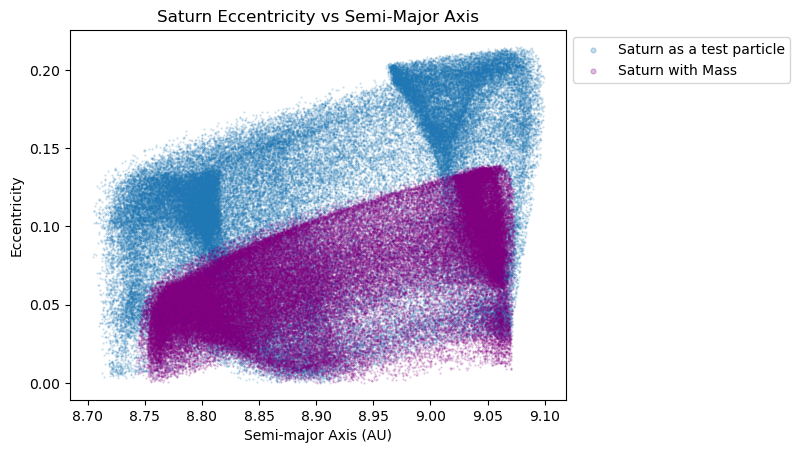

In [16]:
plt.scatter(a_sat_test_particle, e_sat_test_particle, label="Saturn as a test particle", s=0.25, alpha = 0.25)
plt.scatter(a_sat_mass, e_sat_mass, label="Saturn with Mass", s = 0.25, alpha = 0.25, color = 'purple')
plt.xlabel('Semi-major Axis (AU)')
plt.ylabel('Eccentricity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.title('Saturn Eccentricity vs Semi-Major Axis')
plt.show()